# Convergencia de la transformada Z

En el tema 4, vimos que la transformada de Fourier converge o no converge. En cambio, con la transformada Z, la convergencia se da por regiones al ser $z$ un número complejo con módulo y fase. Estas regiones se representan en el plano complejo Z y para cada caso la denominamos **región de convergencia** (**ROC** por sus siglas en inglés).

<img src ="figures/T7/z_plane.png" width = "400">

**Idea: importar toolbox de migmar para dibujar el circulo y que el alumno pueda seleccionar los valores de radio y ángulo para hacer el dibujo**

Teniendo en cuenta que en el plano complejo Z se representan todos los posibles valores de $z$, con módulo generalmente con valor distinto a 1, **la convergencia de la transformada Z se da por regiones** que se representan en el plano Z, a diferencia de la transformada de Fourier.

A continuación, se muestran varios ejemplos de transformada Z para ilustrar dos situaciones y comprender la extracción de las regiones de convergencia a partir de la ecuación de análisis:

<ol>
    <li> Representación de la región de convergencia a partir del módulo de $z$.</li>
    <li> Diferenciación de señales distintas pero con igual transformada Z, diferenciadas por la región de convergencia.</li>
</ol>

**Ejemplo 1**: $x[n] = a^{n}u[n].$

\begin{equation}
 X(z) = \sum_{n=-\infty}^{\infty} x[n]z^{-n} =  \sum_{n=0}^{\infty} a^{n} z^{-n} = \sum_{n=0}^{\infty} \left( \frac{a}{z} \right)^{n}. 
\end{equation}

Para que este sumatorio (suma infinita de una serie geométrica) converja, la razón debe tener módulo inferior a 1:

\begin{equation}
 r = \left| \frac{a}{z} \right| < 1 \rightarrow |z| > |a|.
\end{equation}

Siendo $|z| > |a|$ la región de convergencia de la transformada Z de la señal $x[n]$. Entonces, si hay convergencia, la transformada Z de la señal $x[n]$ se obtiene resolviendo la serie geométrica:

\begin{equation}
 X(z) = \frac{1}{1-r} = \frac{1}{1-\frac{a}{z}} = \frac{1}{1-a z^{-1}}, 
\end{equation}

siendo esta expresión final la que se puede hallar en los pares de transformadas Z de la tabla, donde para cada señal en tiempo discreto mostrada se definen tanto su transformada Z como su región de convergencia. Ilustramos la región de convergencia en el plano Z:

<img src ="figures/T7/example1_ROC.png" width = "400">

**Ejemplo 2**: $x[n] = -a^{n}u[-n-1].$

\begin{equation}
 X(z) = \sum_{n=-\infty}^{\infty} x[n]z^{-n} =  \sum_{n=-\infty}^{-1} -a^{n} z^{-n} = -\sum_{n=-\infty}^{-1} \left( \frac{a}{z} \right)^{n}. 
\end{equation}

Resolvemos este sumatorio con un cambio de variable, siendo $l = -n$, por lo que el sumatorio pasará a estar definido entre 1 e infinito, y se invierte la razón para mantener el exponente positivo:

\begin{equation}
 X(z) = -\sum_{l=1}^{\infty} \left( \frac{z}{a} \right)^{l}. 
\end{equation}

Conviene fijarse en que, al igual que en el ejemplo anterior, para que el sumatorio converja, la razón debe tener módulo inferior a 1. Sin embargo, ahora tenemos la expresión inversa, por lo que:

\begin{equation}
 r = \left| \frac{z}{a} \right| < 1 \rightarrow |z| < |a|.
\end{equation}

Siendo $|z| < |a|$ la región de convergencia de la transformada Z de la señal $x[n]$ en este ejemplo. Entonces, si hay convergencia, la transformada Z de la señal $x[n]$ se obtiene resolviendo la serie:

\begin{equation}
 X(z) = -\sum_{l=1}^{\infty} \left( \frac{z}{a} \right)^{l} = -\frac{r}{1-r} = -\frac{\frac{z}{a}}{1-\frac{z}{a}} = \frac{\frac{a}{z} \cdot \frac{z}{a}}{\frac{a}{z} \cdot \left(\frac{z}{a}-1 \right)} = \frac{1}{1-a z^{-1}},
\end{equation}

siendo esta expresión final la que se puede hallar en los pares de transformadas Z de la tabla. Ilustramos la región de convergencia en el plano Z:

<img src ="figures/T7/example2_ROC.png" width = "400">

Respecto al resultado de los dos ejemplos, es importante fijarse en que, aunque las señales sean distintas, tienen la misma transformada Z, que se diferencia por la región de convergencia. Por lo tanto, **para caracterizar una señal, es necesario tanto la expresión de su transformada como de la región de convergencia**. Resumimos los resultados obtenidos en estos dos ejemplos:

\begin{equation}
 x[n] = a^{n}u[n] \rightarrow X(z) = \frac{1}{1-a z^{-1}}, \text{ROC}: |z| > |a|.
\end{equation}

\begin{equation}
 x[n] = -a^{n}u[-n-1] \rightarrow X(z) = \frac{1}{1-a z^{-1}}, \text{ROC}: |z| < |a|.
\end{equation}

Además, es importante describir el caso de $r=1$, que se corresponde con la **circunferencia unidad**. **Si la circunferencia unidad se encuentra dentro de la ROC, la transformada de Fourier converge** (convergencia sin deltas). 

Partiendo de los dos ejemplos anteriores, asumiendo que $|a|>1$, en la señal definida para tiempos negativos (ejemplo 2, izquierda en la figura de abajo), la transformada de Fourier converge, mientras que en la señal definida para tiempos 0 y positivos (ejemplo 1, derecha en la figura de abajo), la transformada de Fourier no converge, como se ilustra a continuación:

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath(".."))

from utils.plot_helpers import style_math_axes, add_math_ticks

Respecto a la convergencia, la transformada Z presenta una diferencia importante con la transformada de Fourier. La transformada de Fourier converge o no converge. En cambio, con la transformada Z, la convergencia se da por regiones al ser $z$ un número complejo con módulo y fase. Estas regiones se representan en el plano complejo Z y para cada caso la denominamos **región de convergencia** (**ROC** por sus siglas en inglés). A continuación, se muestra un gráfico interactivo para ver cómo se representa el plano complejo en función de módulo y fase.

In [4]:
import numpy as np
from bokeh.plotting import figure, show
from bokeh.layouts import column, row
from bokeh.models import ColumnDataSource, CustomJS, Slider, RadioButtonGroup, Label, Arrow, NormalHead, Button, Div, LabelSet
from bokeh.io import output_notebook

# Importamos tus funciones
# from utils.plot_helpers import style_math_axes, add_math_ticks

output_notebook(verbose=False, hide_banner=True)

# 1. Fuente de datos inicial (Radio 2, Ángulo 45°)
initial_r = 2
initial_phi_deg = 45
initial_phi_rad = np.deg2rad(initial_phi_deg)
initial_x = initial_r * np.cos(initial_phi_rad)
initial_y = initial_r * np.sin(initial_phi_rad)

source = ColumnDataSource(data=dict(x=[initial_x], y=[initial_y]))
# Fuente específica para la cincunferencia dinámica |z|
circle_source = ColumnDataSource(data=dict(r=[initial_r]))
# Fuente para el ángulo Omega (valor pequeño de radio constante)
arc_source = ColumnDataSource(data=dict(r=[initial_r], angle=[initial_phi_rad]))

# 2. Crear la figura
p = figure(
    title="Plano Complejo Z: Control por Radio (r = |z|) y Ángulo (\u03A9)",
    x_range=(-5, 5), y_range=(-5, 5),
    x_axis_label='Re{z}', y_axis_label='Im{z}',
    width=500, height=500
)

"""# Aplicar estilo de ejes
style_math_axes(p, x_range=(-5, 5), y_range=(-5, 5), xlabel="Re{z}", ylabel="Im{z}")

# Marcas (ticks) numéricas en los ejes
ticks = [-4, -2, 2, 4]
add_math_ticks(p, xticks=ticks, xtick_labels=[str(t) for t in ticks],
                  yticks=ticks, ytick_labels=[str(t) for t in ticks])"""

# Parrilla de referencia (cincunferencias grises + etiquetas)
radii = list(range(1, 6))
label_data = dict(x=radii, y=[0.1]*5, names=[f"r={r}" for r in radii])
label_source = ColumnDataSource(data=label_data)

for r in radii:
    p.circle(0, 0, radius=r, fill_color=None, line_color="lightgrey", line_alpha=0.5)

# Etiquetas para las cincunferencias grises
labels = LabelSet(x='x', y='y', text='names', source=label_source, 
                 level='glyph', text_font_size='9pt', text_color="gray")
p.add_layout(labels)

p.line([-5, 5], [0, 0], color="gray", line_dash="dashed")
p.line([0, 0], [-5, 5], color="gray", line_dash="dashed")

# Circunferencia dinámica
p.circle(0, 0, radius='r', source=circle_source, fill_color=None, 
         line_color="navy", line_width=2, line_alpha=0.8)

# Arco dinámico
p.annular_wedge(x=0, y=0, inner_radius=0, outer_radius=0.5,
               start_angle=0, end_angle='angle', source=arc_source,
               color="navy", alpha=0.3, direction="anticlock")

# Elementos gráficos del punto
p.segment(x0=0, y0=0, x1='x', y1='y', source=source, color="navy", line_width=3)
p.circle('x', 'y', source=source, size=12, color="tomato", line_color="black")

# Etiquetas dinámicas
# Etiqueta para |z| (se posiciona en el borde de la circunferencia azul)
label_z = Label(x=0, y=initial_r, text="|z|", text_color="navy", 
                text_font_style="bold", x_offset=5, y_offset=5)
p.add_layout(label_z)

# Etiqueta para Omega 
# La posicionamos en el punto medio del arco (ángulo/2) con un radio fijo de 0.6
label_omega = Label(x=0.6*np.cos(initial_phi_rad/2), y=0.6*np.sin(initial_phi_rad/2), 
                    text="\u03A9", text_color="navy", text_font_style="bold")
p.add_layout(label_omega)

# 3. Sliders
slider_r = Slider(start=0.5, end=5, value=initial_r, step=0.1, title="Radio (r)")
slider_phi = Slider(start=0, end=360, value=initial_phi_deg, step=1, title="Ángulo (en grados)")

btn_reset = Button(label="Reset Parámetros", button_type="default", width=150)

# 4. JavaScript para actualizar según los sliders
callback = CustomJS(args=dict(source=source, c_source=circle_source, arc_source = arc_source, label_z = label_z, label_omega = label_omega, s_r=slider_r, s_phi=slider_phi), code="""
    const r = s_r.value;
    const phi_deg = s_phi.value;
    const phi_rad = phi_deg * Math.PI / 180;
    
    // Calcular nuevas coordenadas cartesianas del punto
    const x = r * Math.cos(phi_rad);
    const y = r * Math.sin(phi_rad);
    
    source.data['x'] = [x];
    source.data['y'] = [y];
    
    // Actualizar radio
    c_source.data['r'] = [r];
    
    // Actualizar arco
    arc_source.data['r'] = [r];
    arc_source.data['angle'] = [phi_rad];
    
    // Actualizar etiqueta |z| (movimiento en posición vertical)
    label_z.y = r;
    
    // Actualizar etiqueta Omega (al punto medio del arco para que no se solape)
    const mid_phi = phi_rad / 2;
    label_omega.x = 0.7 * Math.cos(mid_phi);
    label_omega.y = 0.7 * Math.sin(mid_phi);
    
    source.change.emit();
    c_source.change.emit();
    arc_source.change.emit();
""")

slider_r.js_on_change('value', callback)
slider_phi.js_on_change('value', callback)

# Callback Reset
callback_reset = CustomJS(
    args=dict(slider_r=slider_r, slider_phi=slider_phi, v_r=initial_r, v_phi=initial_phi_deg),
    code="""
    slider_r.value = v_r;
    slider_phi.value = v_phi;
""")
btn_reset.js_on_event('button_click', callback_reset)

# 5. Caption
texto_caption = """
<div style="font-family: sans-serif; font-size: 14px; opacity: 0.8; text-align: justify;">
    <b>Representación del plano Z.</b> La circunferencia azul muestra los puntos para un valor |z| (r) y el arco el ángulo (\u03A9).
</div>
"""
caption = Div(text=texto_caption, width=500, sizing_mode="fixed")

# 6. Organizar layout y mostrar
layout = column(slider_r, slider_phi, btn_reset, p, caption)
show(layout)

In [2]:
import numpy as np
from bokeh.plotting import figure, show
from bokeh.layouts import column, row
from bokeh.models import ColumnDataSource, CustomJS, Slider, Div, Label, LabelSet
from bokeh.io import output_notebook

output_notebook(verbose=False, hide_banner=True)

# 1. Parámetros iniciales
initial_a = 0.8
angle_a = np.pi / 4      # 45 grados para el radio 'a'
angle_unit = 3 * np.pi / 4 # 135 grados para el radio unitario

source_radius_a = ColumnDataSource(data=dict(
    x0=[0], y0=[0], 
    x1=[initial_a * np.cos(angle_a)], 
    y1=[initial_a * np.sin(angle_a)],
    text=["|a|"]
))

source_radius_unit = ColumnDataSource(data=dict(
    x0=[0], y0=[0], 
    x1=[np.cos(angle_unit)], # Exactamente en el radio 1
    y1=[np.sin(angle_unit)],
    text=["r=1"]
))

source_causal = ColumnDataSource(data=dict(inner=[initial_a], outer=[10]))
source_anticausal = ColumnDataSource(data=dict(inner=[0], outer=[initial_a]))
source_a = ColumnDataSource(data=dict(r=[initial_a]))

# 2. Función para crear el plano Z
def create_z_plane(title):
    fig = figure(title=title, x_range=(-3, 3), y_range=(-3, 3),
                 width=400, height=400, x_axis_label='Re{z}', y_axis_label='Im{z}')
    
    fig.line([-3, 3], [0, 0], color="black", alpha=0.2)
    fig.line([0, 0], [-3, 3], color="black", alpha=0.2)

    # --- Círculo Unitario (Más grueso como pediste) ---
    fig.circle(0, 0, radius=1, line_dash="dashed", line_color="gray", fill_alpha=0, line_width=2)
    
    # Segmento r=1
    fig.segment(x0='x0', y0='y0', x1='x1', y1='y1', source=source_radius_unit, 
                color="gray", line_width=1.5, line_dash="dotted")
    
    # Etiqueta r=1 (Más cerca: reduciendo offsets)
    labels_u = LabelSet(x='x1', y='y1', text='text', source=source_radius_unit,
                        x_offset=-25, y_offset=0, text_color="gray", text_font_size="9pt")
    fig.add_layout(labels_u)

    # --- Radio 'a' ---
    fig.segment(x0='x0', y0='y0', x1='x1', y1='y1', source=source_radius_a, 
                color="red", line_width=2)
    labels_a = LabelSet(x='x1', y='y1', text='text', source=source_radius_a,
                        x_offset=5, y_offset=5, text_color="red", text_font_style="bold")
    fig.add_layout(labels_a)
    
    return fig

# Títulos con superíndice Unicode (\u207F es 'n')
p1 = create_z_plane("Causal: x[n] = a\u207F u[n]")
p2 = create_z_plane("Anticausal: x[n] = -a\u207F u[-n-1]")

# 3. Dibujar ROCs
for p, src in zip([p1, p2], [source_causal, source_anticausal]):
    p.annular_wedge(x=0, y=0, inner_radius='inner', outer_radius='outer',
                    start_angle=0, end_angle=2*np.pi, source=src,
                    color="orange", alpha=0.25)
    p.circle(0, 0, radius='r', source=source_a, line_color="red", line_width=2, fill_alpha=0)

# 4. Etiquetas de Convergencia (Estado inicial manual para que aparezca al cargar)
def get_conv_text(a, causal=True):
    if causal:
        return ("TF converge (|a| < 1)", "green") if a < 1 else ("TF no converge (|a| \u2265 1)", "red")
    else:
        return ("TF converge (|a| > 1)", "green") if a > 1 else ("TF no converge (|a| \u2264 1)", "red")

txt1, col1 = get_conv_text(initial_a, True)
txt2, col2 = get_conv_text(initial_a, False)

label_conv1 = Label(x=-2.8, y=2.5, text=txt1, text_color=col1, text_font_style="italic")
label_conv2 = Label(x=-2.8, y=2.5, text=txt2, text_color=col2, text_font_style="italic")
p1.add_layout(label_conv1)
p2.add_layout(label_conv2)

# 5. Slider y JavaScript
slider_a = Slider(start=0.1, end=2.5, value=initial_a, step=0.1, title="Valor de |a|")

callback = CustomJS(args=dict(s_causal=source_causal, s_anti=source_anticausal, 
                              s_a=source_a, s_rad_a=source_radius_a, s_val=slider_a,
                              l1=label_conv1, l2=label_conv2, angle=angle_a), code="""
    const a = s_val.value;
    s_rad_a.data['x1'] = [a * Math.cos(angle)];
    s_rad_a.data['y1'] = [a * Math.sin(angle)];
    s_a.data['r'] = [a];
    s_causal.data['inner'] = [a];
    s_anti.data['outer'] = [a];
    
    if (a < 1) {
        l1.text = "TF converge (|a| < 1)"; l1.text_color = "green";
    } else {
        l1.text = "TF no converge (|a| \u2265 1)"; l1.text_color = "red";
    }
    
    if (a > 1) {
        l2.text = "TF converge (|a| > 1)"; l2.text_color = "green";
    } else {
        l2.text = "TF no converge (|a| \u2264 1)"; l2.text_color = "red";
    }
    
    s_rad_a.change.emit();
    s_a.change.emit();
    s_causal.change.emit();
    s_anti.change.emit();
""")

slider_a.js_on_change('value', callback)

# 6. Layout
caption = Div(text="""
<div style="font-family: sans-serif; font-size: 14px; opacity: 0.8; text-align: justify; border-left: 3px solid orange; padding-left: 10px;">
    <b>Análisis de Convergencia.</b> La región naranja representa la ROC en el plano Z. Se muestran los radios críticos: el radio del polo <b>|a|</b> (rojo) y el radio unitario <b>r=1</b> (gris). La Transformada de Fourier existe si y solo si la ROC incluye el círculo unitario.
</div>
""", sizing_mode="scale_width")

layout = column(slider_a, row(p1, p2), caption, sizing_mode="scale_width", width=500)
show(layout)

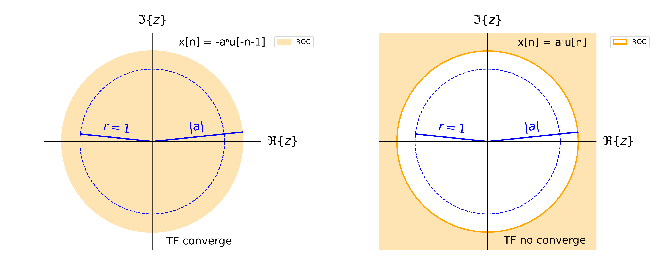

In [5]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# read images
img_1 = mpimg.imread('figures/T7/example2_ROC_r1.png')
img_2 = mpimg.imread('figures/T7/example1_ROC_r1.png')

# create subplot axis
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(11,8))

# plot the images
ax1.imshow(img_1)
ax2.imshow(img_2)

# turn off the axis
ax1.axis('off')
_ = ax2.axis('off')
#ax2.axis('off')

# 5. Avoid unnecesary blank spaces
#plt.tight_layout()

# 6. Force clean output
#plt.show()

**Propuesta**: Adaptar el código de arriba con el toolbox de Miguel para que, para un valor concreto de $|a|$ (permitiendo solamente valores reales positivos) para cada uno de los dos casos, se indique si la TF converge o no a partir de un mensaje por pantalla que se encuentre junto con las figuras (o debajo) representadas arriba. 

## Propiedades de la región de convergencia

A continuación, se definen diversas propiedades de interés de la transformada Z:

1. La ROC **no contiene ningún polo** por definición. Recordando la definición de polo:

\begin{equation}
 \lim_{z\to z_0} |X(z)| = \infty.
\end{equation}

En este caso, $|z| = |z_0|$ no está incluida en la ROC.

2. La ROC de $X(z)$ son **anillos** en el plano Z **centrados en el origen de coordenadas**. Ejemplo gráfico:

<img src ="figures/T7/ring1_ROC.png" width = "400">

En este caso, cabe remarcar que tanto $|z| = |a|$ como $|z| = |b|$ no están dentro de la ROC debido a que hay polos para ambos valores (primera propiedad). Expresando la transformada Z como la transformada de Fourier de la señal $x[n]r^{-n}$, hay convergencia si:

\begin{equation}
 \sum_{n=-\infty}^{\infty} |x[n]|r^{-n} < \infty,
\end{equation}

lo que implica que la convergencia depende del valor de $r$ y no del valor de $\Omega$, dando lugar a regiones de convergencia circulares centradas en el origen.

3. Si la ROC **contiene a la circunferencia unidad**, $|z|=1$, **la transformada de Fourier converge** (convergencia sin deltas de Dirac en la transformada de Fourier), como se mostró anteriormente.

4. Si la **señal es de duración finita**, la ROC será **todo el plano Z, con posibles excepciones en el origen y el infinito**.

\begin{equation}
 x[n] = 0 \text{ en } n<n_0 \text{ y } n>n_1 \rightarrow \text{ROC: } Z \pm \{0\} \pm \{\infty\}.
\end{equation}

<ul>
  <li> $n_0<0 \text{ } \& \text{ } n_1>0$: $\text{ROC }= Z - \{0\} - \{\infty\}$. Ejemplo: $x[n] = \delta[n-1] + \delta[n+1] \rightarrow X(z) = z^{-1} + z. \text{ ROC }= Z - \{0\} - \{\infty\}$.
  <li> $n_0\geq 0$: $\text{ROC }= Z - \{0\} + \{\infty\}$. Ejemplo: $x[n] = \delta[n-1] \rightarrow X(z) = z^{-1}. \text{ ROC: } Z - \{0\}$.
  <li> $n_1\leq 0$: $\text{ROC }= Z + \{0\} - \{\infty\}$. Ejemplo: $x[n] = \delta[n+1] \rightarrow X(z) = z. \text{ ROC: } Z - \{\infty\}$.
  <li> $n_0 = n_1 = 0$: $\text{ROC }= Z + \{0\} + \{\infty\}$. $x[n] = \delta[n] \rightarrow X(z) = 1. \text{ ROC: } Z$ (todo el plano).
</ul>

5. Si la **señal es una secuencia derecha** ($x[n]=0 \text{ para } n < n_0$), y la ROC contiene $r=r_0$, la ROC contiene todos los valores finitos de $z$ tales que $r > r_0$. La **convergencia se da desde el polo de mayor módulo hacia el exterior**.

Demostramos matemáticamente la convergencia:

\begin{equation}
 \sum_{n=n_{0}}^{\infty} |x[n]|r_{0}^{-n} < \infty \Rightarrow \sum_{n=n_{0}}^{\infty} |x[n]|r^{-n} = \sum_{n=n_{0}}^{\infty} |x[n]|r_{0}^{-n} \cdot \left( \frac{r_{0}}{r} \right)^{n} < \infty,
\end{equation}

la convergencia se da si $\left( \frac{r_{0}}{r} \right) < 1$, esto es, $r > r_{0}$. Lo mostramos gráficamente:

<img src ="figures/T7/causal_ROC_right.png" width = "400">

Hay que tener cuidado con lo que ocurre en infinito:

<ul>
  <li> Si $n_0<0$: $\text{ROC } \not\subset \{\infty\}$.
  <li> Si $n_0\geq 0$: $\text{ROC } \subset \{\infty\}$. 
</ul>

6. Si la **señal es una secuencia izquierda** ($x[n]=0 \text{ para } n > n_0$), y la ROC contiene $r=r_0$, la ROC contiene todos los valores finitos de $z$ tales que $r < r_0$. La **convergencia se da desde el polo de menor módulo hacia el interior**.

Demostramos matemáticamente la convergencia:

\begin{equation}
 \sum_{n=-\infty}^{n_{0}} |x[n]|r_{0}^{-n} < \infty \Rightarrow \sum_{n=-\infty}^{n_{0}} |x[n]|r^{-n} = \sum_{n=-\infty}^{n_{0}} |x[n]|r_{0}^{-n} \cdot \left( \frac{r_{0}}{r} \right)^{n} < \infty,
\end{equation}

la convergencia se da si $\left( \frac{r_{0}}{r} \right) > 1$, esto es, $r < r_{0}$. Lo mostramos gráficamente:

<img src ="figures/T7/anticausal_ROC_left.png" width = "400">

Hay que tener cuidado con lo que ocurre en el origen:

<ul>
  <li> Si $n_0>0$: $\text{ROC } \not\subset \{0\}$.
  <li> Si $n_0\leq 0$: $\text{ROC } \subset \{0\}$. 
</ul>

7. Si la **señal es una secuencia bilateral**, esto es, la suma de una secuencia derecha con otra izquierda ($x[n] = x_d[n] + x_i[n]$), y la circunferencia $r=r_0$ está en la ROC, la **ROC será un anillo que contenga $r_{0}$**.

La transformada Z será:

\begin{equation}
 X(z) = \sum_{n=-\infty}^{\infty} x[n] z^{-n} = \sum_{n=0}^{\infty} x_d[n] z^{-n} + \sum_{n=-\infty}^{-1} x_i[n] z^{-n}.
\end{equation}

La ROC, en caso de existir, será (por lo menos) la intersección de las ROC de las secuencias derecha e izquierda:

\begin{equation}
 \text{ROC } \subset \text{ROC}_d \cap \text{ ROC}_i.
\end{equation}

Ilustramos esta propiedad con un ejemplo:

**Ejemplo 3**: $x[n] = a^{|n|}, a \in \Re^{+}.$

Expresamos la señal como una suma de secuencias derecha e izquierda:

\begin{equation}
 x[n] = x_d[n] + x_i[n] = a^{n} \cdot u[n] + a^{-n} \cdot u[-n-1].
\end{equation}

La transformada Z es la suma de las transformadas Z de las secuencias derecha e izquierda, que son casos similares mostrados a los ejemplos 1 y 2:

\begin{equation}
 X_d(z) = \frac{1}{1-az^{-1}}, |z|>a; \quad X_i(z) = \frac{-1}{1-(az)^{-1}}=\frac{-1}{1-\frac{1}{a}z^{-1}}, |z| < \frac{1}{a}.
\end{equation}

\begin{equation}
 X(z) = \begin{cases}
  \frac{1}{1-az^{-1}} - \frac{1}{1-\frac{1}{a}z^{-1}},& \text{ ROC= } a < |z| < \frac{1}{a},& \text{ si } a<1, \\
  \text{No existe},& \text{ ROC= } \emptyset ,& \text{ si } a\geq1.
 \end{cases}
\end{equation}

Ilustramos las regiones de convergencia de $X_d(z)$, $X_i(z)$ y $X(z)$ si $a < 1$ (de izquierda a derecha en la figura de abajo).

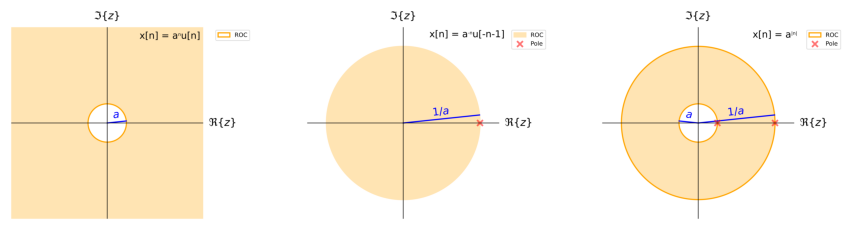

In [1]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

# read images
img_1 = mpimg.imread('figures/T7/example3_ROC_right.png')
img_2 = mpimg.imread('figures/T7/example3_ROC_left.png')
img_3 = mpimg.imread('figures/T7/example3_ring.png')

# create subplot axis
fig, axs = plt.subplots(1,3,figsize=(15,11))

# plot the images
axs[0].imshow(img_1)
axs[1].imshow(img_2)
axs[2].imshow(img_3)

# turn off the axis
axs[0].axis('off')
_ = axs[1].axis('off')
_ = axs[2].axis('off')